In [233]:
devtools::install_github("WorldWeatherAttribution/rwwa")
library(rwwa)

Using GitHub PAT from the git credential store.

Skipping install of 'rwwa' from a github remote, the SHA1 (236d9a6b) has not changed since last install.
  Use `force = TRUE` to force installation



In [234]:
your_save_directory <- "../data"

# Synthesise results from observations and climate models

In [235]:
observations_path <- file.path(your_save_directory, "res-obs_era5.csv")

# load the observational results
df_obs <- read.csv(observations_path, row.names = "X")

In [236]:
df_obs

,mu0_est,mu0_lower,mu0_upper,sigma0_est,sigma0_lower,sigma0_upper,alpha_gmst_est,alpha_gmst_lower,alpha_gmst_upper,shape_est,⋯,dI_abs_upper,dI_rel_est,dI_rel_lower,dI_rel_upper,aic_est,aic_lower,aic_upper,n_est,n_lower,n_upper
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>,<int>
era5,88.70773,74.11155,112.2279,35.02551,28.48205,43.34563,14.86953,-14.30867,56.5116,0.1578477,⋯,99.73876,24.34764,-16.30892,96.61639,774.4397,741.8094,796.2831,75,500,0


In [237]:
models_path = file.path(your_save_directory, "res-models-Future-2.6.csv")

# load the climate model results
df_models <- read.csv(models_path, row.names = "X")

In [238]:
df_models

,Include,eval_sigma0_est,eval_sigma0_lower,eval_sigma0_upper,eval_shape_est,eval_shape_lower,eval_shape_upper,rp_value,attr_PR_est,attr_PR_lower,⋯,proj_dI.rel_upper,aic_eval,aic_attr,aic_proj,attr_nobs,attr_nsamp,attr_nfailed,proj_nobs,proj_nsamp,proj_nfailed
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>,<int>,<int>,<int>,<int>
cccma_canesm2_clmcom_clm_cclm4_8_17,False,1.722354,1.437014,1.906026,-0.1360382,-0.3504190,-0.01410695,24.01937,2.712648,2.112300,⋯,9.184578,318.3774,318.3774,663.0630,76,10,0,151,10,0
cccma_canesm2_gerics_remo2015,True,1.394018,1.180128,1.546610,-0.2099927,-0.3440599,-0.11261795,22.10735,2.194869,1.417325,⋯,6.386286,279.4483,279.4483,555.2037,76,10,0,151,10,0
access_cm2,False,1.550926,1.339167,1.612269,-0.1746515,-0.2313086,-0.05252414,22.83256,2.938280,1.333819,⋯,7.894760,567.6344,567.6344,842.9172,146,10,0,221,10,0
canesm5,True,1.243837,1.139736,1.295533,-0.3164296,-0.4137032,-0.26084315,22.94742,4.453065,3.066471,⋯,7.656931,478.6214,478.6214,729.1136,146,10,0,221,10,0


In [239]:
# Should we make a little R library as well? Is this easy to include in the py library?

filter_models <- function(df, include = c("true", "false", "both")) {
    include <- match.arg(include)

    if (include == "true") {
        df <- df[df$Include == TRUE, ]
    } else if (include == "false") {
    df <- df[df$Include == FALSE, ]
    } 
    # "both" returns df unchanged

    df
}


In [240]:
# Maybe change the name for this column

df_models$Include <- as.logical(df_models$Include)
# Only models with Include == TRUE
df_models <- filter_models(df_models, "true")

In [241]:
# if looking at temperature data / 'shift' fit, use "abs";
# if looking at precipitation / 'fixeddisp', use "rel";
# use PR for probability ratio
synthesis_type <- "abs"

In [242]:
# change in intensity from past-present
synth_dI_attr <- synthesis(obs_in = df_obs[,grepl(paste0("dI.", synthesis_type), colnames(df_obs))], 
                           models_in = df_models[,grepl(paste0("attr_dI.", synthesis_type), colnames(df_models))], 
                           synth_type = synthesis_type)
synth_dI_attr
# if you see error/warning messages below, you probably have infinite best estimates in your observations - ask us how to handle these

group,model,est,lower,upper,l_wb,u_wb
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
obs,era5,39.743605,-39.5573765,99.738761,-39.5573765,99.738761
obs_synth,Observations,39.743605,-39.5573765,99.738761,NA,NA
models,cccma_canesm2_gerics_remo2015,1.236046,0.6592519,2.022262,0.6592519,2.022262
models,canesm5,1.613586,1.2681126,1.913421,1.2681126,1.913421
model_synth,Models,1.544456,1.1464416,1.976456,NA,NA
synth,Synthesis,1.545812,0.9280080,2.106536,-35.4309376,63.068112


In [ ]:

# change in likelihood from past-present (if there are any infinite values in the PRs, replace them with estimated values)
synth_PR_attr <- synthesis(obs_in = infer_infinite(df_obs[,grepl("PR", colnames(df_obs))]), 
                           models_in = infer_infinite(df_models[,grepl("attr_PR", colnames(df_models))]), 
                           synth_type = "PR")
synth_PR_attr
# if you see error/warning messages below, you probably have infinite best estimates in your observations - ask us how to handle these

group,model,est,lower,upper,l_wb,u_wb
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
obs,era5,2.335508,0.1425413,10.128937,0.1425413,10.128937
obs_synth,Observations,2.335508,0.1425413,10.128937,NA,NA
models,cccma_canesm2_gerics_remo2015,2.194869,1.4173249,5.255156,0.9105923,6.999743
models,canesm5,4.453065,3.0664706,10.024327,1.9039575,13.567272
model_synth,Models,3.171298,1.3362911,9.878467,NA,NA
synth,Synthesis,3.000999,0.7236912,9.990429,0.3435519,10.108257


In [244]:
# change in intensity from present-future
synth_dI_proj <- synthesis(obs_in = NA, 
                           models_in = df_models[,grepl(paste0("proj_dI.", synthesis_type), colnames(df_models))], 
                           synth_type = synthesis_type)
synth_dI_proj


,group,model,est,lower,upper,l_wb,u_wb
,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
3,models,cccma_canesm2_gerics_remo2015,1.299453,1.2209952,1.496930,0.5331839,2.08686
4,models,canesm5,1.859584,1.7918212,1.928568,1.0943358,2.62494
5,model_synth,Models,1.582910,0.8171576,2.359237,NA,NA


In [245]:
# change in likelihood from present-future
synth_PR_proj <- synthesis(obs_in = NA, 
                           models_in = df_models[,grepl("proj_PR", colnames(df_models))], 
                           synth_type = "PR")
synth_PR_proj                           

,group,model,est,lower,upper,l_wb,u_wb
,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
3,models,cccma_canesm2_gerics_remo2015,1.528803,1.495352,1.625575,1.331977,1.774863
4,models,canesm5,1.694971,1.670828,1.708093,1.478278,1.942386
5,model_synth,Models,1.613212,1.406274,1.860507,NA,NA


In [246]:
# save all the synthesised results
write.csv(synth_dI_attr$df, file.path(your_save_directory, "synth_dI_attr.csv"))
write.csv(synth_PR_attr$df, file.path(your_save_directory, ".synth_PR_attr.csv"))
write.csv(synth_dI_proj$df, file.path(your_save_directory, "synth_dI_proj.csv"))
write.csv(synth_PR_proj$df, file.path(your_save_directory, "synth_PR_proj.csv"))

## Synthesis figures

In [247]:
prep_rc = c(1, 2)
prep_h = 5                      # height of the figure (ins)
prep_w = 5                      # width of the figure (ins)
prep_res = 200
prep_pch = 20
prep_oma = c(0, 14, 0, 0)       # increase second number until model names fit in margin
prep_mar = c(3, .5, 2, .5)      # shouldn't need to be changed

x_lim_dI = c(-80, 100)          # Change until the bars fit the plot
x_lim_PR = c(1e-2, 1e2)         # Change until the bars fit the plot

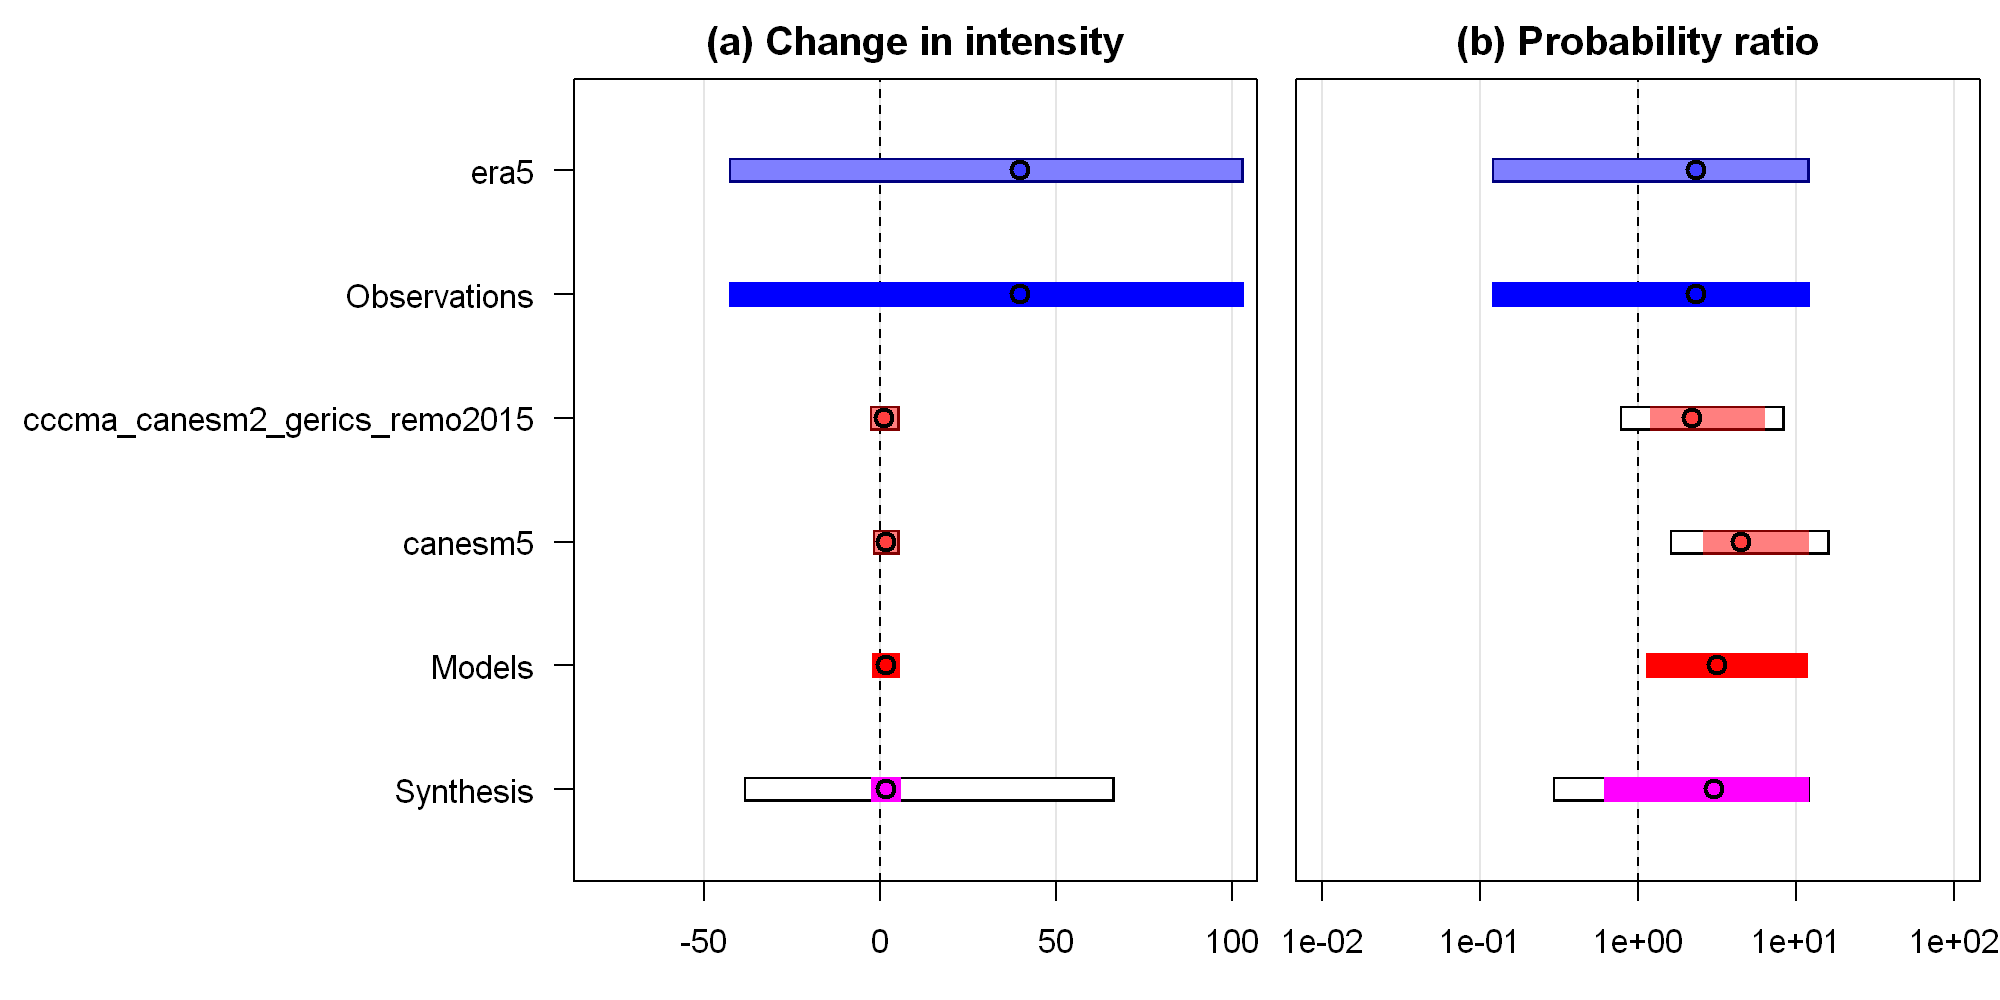

In [248]:
# put two figures next to each other
prep_window(prep_rc,
            h = prep_h,         # height of the figure (ins)
            w = prep_w,         # width of each panel (ins)
            res = prep_res,
            pch = prep_pch,
            oma = prep_oma,     # width of each panel (ins)
            mar = prep_mar)     # shouldn't need to be changed

# set the x-axis (xlim) so that both the past & future changes use the same scaling
plot_synthesis(synth_dI_attr, lwd=12, add_space = F, main = "(a) Change in intensity", xlim = x_lim_dI)
plot_synthesis(synth_PR_attr, lwd=12, add_space = F, hide_labels = T, main = "(b) Probability ratio", xlim = x_lim_PR)

In [249]:
attr_export_path <- file.path(your_save_directory, "synth-fig_attr.png")

png(attr_export_path, height = 360, width = 480*1.5); par(mfrow = prep_rc, oma = prep_oma, mar = prep_mar); {
    # set the x-axis (xlim) so that both the past & future changes use the same scaling
    plot_synthesis(synth_dI_attr, add_space = F, main = "(a) Change in intensity", xlim = x_lim_dI)
    plot_synthesis(synth_PR_attr, add_space = F, hide_labels = T, main = "(b) Probability ratio", xlim = x_lim_PR)
}; dev.off()

agg_record_1325632562 
                    2

In [250]:
prep_rc = c(1, 2)
prep_h = 5                      # height of the figure (ins)
prep_w = 5                      # width of the figure (ins)
prep_res = 200
prep_pch = 20
prep_oma = c(0, 14, 0, 0)       # increase second number until model names fit in margin
prep_mar = c(3, .5, 2, .5)      # shouldn't need to be changed

x_lim_dI = c(-80, 100)          # Change until the bars fit the plot
x_lim_PR = c(1, 2.5)            # Change until the bars fit the plot

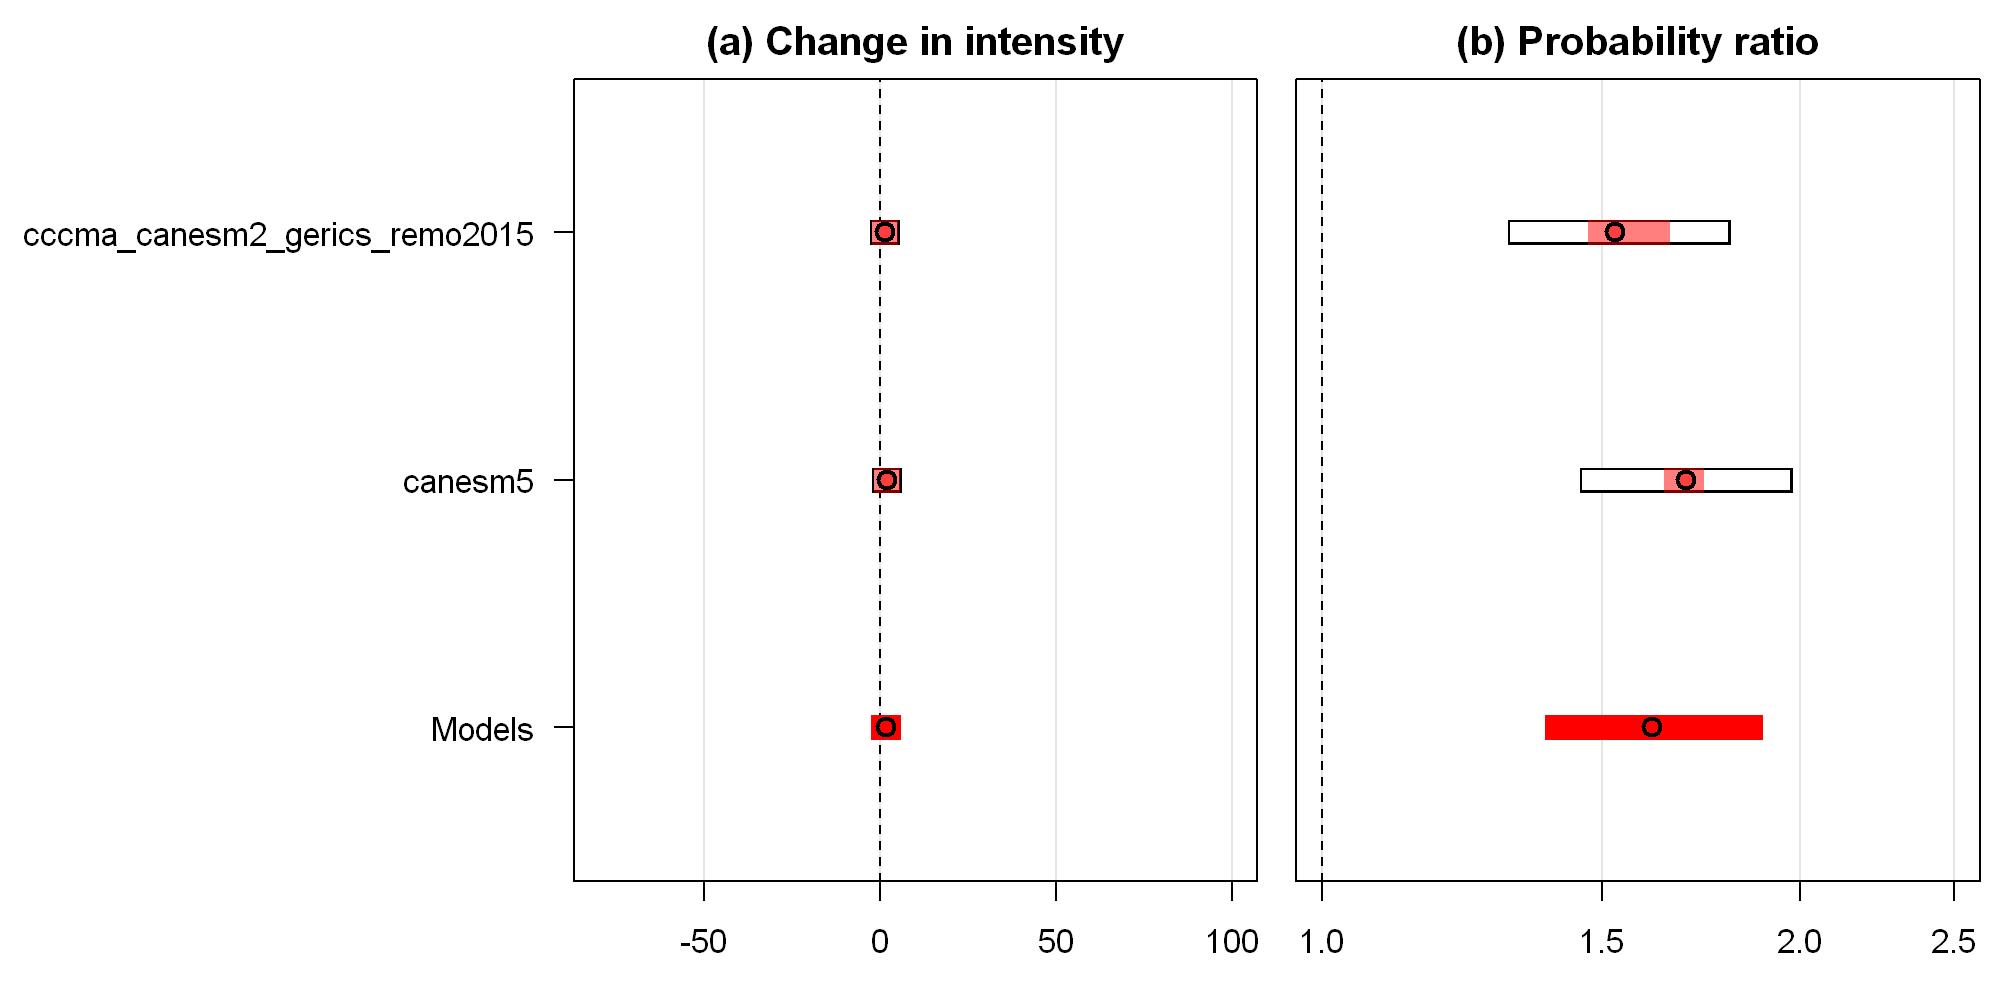

In [251]:
prep_window(prep_rc,
            h = prep_h,         # height of the figure (ins)
            w = prep_w,         # width of each panel (ins)
            res = prep_res,
            pch = prep_pch,
            oma = prep_oma,     # increase second number until model names fit in margin
            mar = prep_mar)     # shouldn't need to be changed

# set the x-axis (xlim) so that both the past & future changes use the same scaling
plot_synthesis(synth_dI_proj, lwd=12, add_space = F, main = "(a) Change in intensity", xlim = x_lim_dI)
plot_synthesis(synth_PR_proj, lwd=12, add_space = F, hide_labels = T, main = "(b) Probability ratio", xlim = x_lim_PR)

## Produce figures of the synthesis

In [252]:
proj_export_path <- file.path(your_save_directory, "synth-fig_proj.png")

png(proj_export_path, height = 240, width = 480*1.5); par(mfrow = prep_rc, oma = prep_oma, mar = prep_mar); {
    # set the x-axis (xlim) so that both the past & future changes use the same scaling
    plot_synthesis(synth_dI_proj, add_space = F, main = "(a) Change in intensity", xlim = x_lim_dI)
    plot_synthesis(synth_PR_proj, add_space = F, hide_labels = T, main = "(b) Probability ratio", xlim = x_lim_PR)
}; dev.off()

agg_record_1390812906 
                    2

In [253]:
# Cells below are for testing to produce table outputs

colnames(df_models)

[1] "Include"           "eval_sigma0_est"   "eval_sigma0_lower"
 [4] "eval_sigma0_upper" "eval_shape_est"    "eval_shape_lower" 
 [7] "eval_shape_upper"  "rp_value"          "attr_PR_est"      
[10] "attr_PR_lower"     "attr_PR_upper"     "attr_dI.abs_est"  
[13] "attr_dI.abs_lower" "attr_dI.abs_upper" "attr_dI.rel_est"  
[16] "attr_dI.rel_lower" "attr_dI.rel_upper" "proj_PR_est"      
[19] "proj_PR_lower"     "proj_PR_upper"     "proj_dI.abs_est"  
[22] "proj_dI.abs_lower" "proj_dI.abs_upper" "proj_dI.rel_est"  
[25] "proj_dI.rel_lower" "proj_dI.rel_upper" "aic_eval"         
[28] "aic_attr"          "aic_proj"          "attr_nobs"        
[31] "attr_nsamp"        "attr_nfailed"      "proj_nobs"        
[34] "proj_nsamp"        "proj_nfailed"

In [254]:
obs_cols <- colnames(df_obs)
model_cols <- colnames(df_models)

diff_cols <- setdiff(union(obs_cols, model_cols), intersect(obs_cols, model_cols))
diff_cols

[1] "mu0_est"               "mu0_lower"             "mu0_upper"            
 [4] "sigma0_est"            "sigma0_lower"          "sigma0_upper"         
 [7] "alpha_gmst_est"        "alpha_gmst_lower"      "alpha_gmst_upper"     
[10] "shape_est"             "shape_lower"           "shape_upper"          
[13] "disp_est"              "disp_lower"            "disp_upper"           
[16] "event_magnitude_est"   "event_magnitude_lower" "event_magnitude_upper"
[19] "return_period_est"     "return_period_lower"   "return_period_upper"  
[22] "PR_est"                "PR_lower"              "PR_upper"             
[25] "dI_abs_est"            "dI_abs_lower"          "dI_abs_upper"         
[28] "dI_rel_est"            "dI_rel_lower"          "dI_rel_upper"         
[31] "aic_est"               "aic_lower"             "aic_upper"            
[34] "n_est"                 "n_lower"               "n_upper"              
[37] "Include"               "eval_sigma0_est"       "eval_sigma0_lower"    
[40] "eval_sigma0_upper"     "eval_shape_est"        "eval_shape_lower"     
[43] "eval_shape_upper"      "rp_value"              "attr_PR_est"          
[46] "attr_PR_lower"         "attr_PR_upper"         "attr_dI.abs_est"      
[49] "attr_dI.abs_lower"     "attr_dI.abs_upper"     "attr_dI.rel_est"      
[52] "attr_dI.rel_lower"     "attr_dI.rel_upper"     "proj_PR_est"          
[55] "proj_PR_lower"         "proj_PR_upper"         "proj_dI.abs_est"      
[58] "proj_dI.abs_lower"     "proj_dI.abs_upper"     "proj_dI.rel_est"      
[61] "proj_dI.rel_lower"     "proj_dI.rel_upper"     "aic_eval"             
[64] "aic_attr"              "aic_proj"              "attr_nobs"            
[67] "attr_nsamp"            "attr_nfailed"          "proj_nobs"            
[70] "proj_nsamp"            "proj_nfailed"